The [vscodenb](https://munch-group.org/docs/vscodenb) is a small library I wrote with utilities for working with notebooks in VS Code. `set_vscode_theme` makes plots and widgets look better and match the your use of light / dark theme in VS Code.

In [1]:
import numpy as np
import time

from vscodenb import set_vscode_theme
set_vscode_theme()

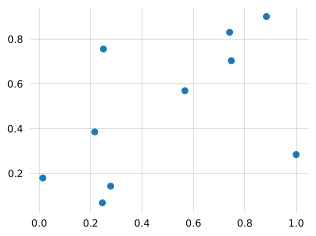

In [2]:
import matplotlib.pyplot as plt
plt.scatter(np.random.random(10), np.random.random(10)) ;

## Cell Magic

One of its features is monitoring CPU and memory usage while running notebook cells. This can be useful when working with Phasic if you want to monitor CPU load balancing and memory use. The `%%monitor` cell magic is the simplest way to monitor CPU usage. Just add it at the top of any cell:

In [3]:
%%monitor -p

# A simple computation
for i in range(10):
    result = sum(range(5_000_000))
    time.sleep(0.5)

You can customize the display width:

In [4]:
%%monitor -w 100

print("Running with custom width...")
for i in range(4):
    x = sum(range(3_000_000))
    time.sleep(0.5)
print("Complete!")

Running with custom width...


Complete!


Increase update frequency for smoother visualization:

In [5]:
%%monitor -i 0.25

# Updates 4 times per second
print("Fast updates enabled...")
for i in range(8):
    result = sum(range(2_000_000))
    time.sleep(0.3)
print("Done with fast updates!")

Fast updates enabled...


Done with fast updates!


## Context Manager: For Scripts

The context manager gives you explicit control over monitoring.
Perfect for Python scripts or when you want programmatic control.

### Basic Context Manager

In [6]:
print("Using context manager...")

from vscodenb import CPUMonitor

with CPUMonitor():
    # Your computation here
    for i in range(5):
        result = sum(range(4_000_000))
        time.sleep(0.5)

print("Monitoring complete!")

Using context manager...


Monitoring complete!


### Custom Configuration

In [7]:
print("Custom configuration...")

with CPUMonitor(update_interval=0.3, width=120):
    print("  Phase 1: Light computation")
    for i in range(3):
        x = sum(range(1_000_000))
        time.sleep(0.4)
    
    print("  Phase 2: Heavy computation")
    for i in range(3):
        x = sum(range(5_000_000))
        time.sleep(0.4)

print("Both phases complete!")

Custom configuration...


  Phase 1: Light computation


  Phase 2: Heavy computation


Both phases complete!


### Disable Summary (for quick tests)

In [8]:
# No summary statistics - just live monitoring
with CPUMonitor(show_summary=False):
    for i in range(4):
        x = sum(range(2_000_000))
        time.sleep(0.4)

print("Done (no summary)")

Done (no summary)


## Decorator: For Functions

Wrap any function with `@monitor_cpu` to automatically monitor its execution.

### Basic Decorator

In [9]:
from vscodenb import monitor

@monitor
def simulate_training():
    """Simulate a training process."""
    print("Training started...")
    for epoch in range(5):
        print(f"  Epoch {epoch+1}/5")
        # Simulate computation
        loss = sum(range(3_000_000))
        time.sleep(0.5)
    print("Training complete!")
    return "model.pkl"

# Run the decorated function
model_file = simulate_training()
print(f"\nSaved to: {model_file}")

Training started...
  Epoch 1/5


  Epoch 2/5


  Epoch 3/5


  Epoch 4/5


  Epoch 5/5


Training complete!



Saved to: model.pkl


### Decorator with Custom Settings

In [10]:
@monitor(update_interval=0.25, show_summary=True)
def process_data(n_iterations):
    """Process data in batches."""
    print(f"Processing {n_iterations} batches...")
    results = []
    for i in range(n_iterations):
        # Simulate batch processing
        batch_result = sum(range(2_000_000))
        results.append(batch_result)
        time.sleep(0.3)
    return results

# Execute
results = process_data(6)
print(f"\nProcessed {len(results)} batches")

Processing 6 batches...



Processed 6 batches


## Real Computations <a id="real-computations"></a>

Let's monitor some actual computational work!

### Matrix Operations

In [11]:
%%monitor

print("Performing large matrix operations...\n")

# Create large matrices
n = 1500
print(f"1. Creating {n}*{n} matrices...")
A = np.random.randn(n, n)
B = np.random.randn(n, n)

print(f"2. Matrix multiplication...")
C = np.dot(A, B)

print(f"3. Computing eigenvalues...")
eigenvalues = np.linalg.eigvals(C[:400, :400])

print(f"4. SVD decomposition...")
U, s, Vh = np.linalg.svd(C[:400, :400], full_matrices=False)

print(f"\nComplete!")
print(f"  Eigenvalues computed: {len(eigenvalues)}")
print(f"  Singular values computed: {len(s)}")

Performing large matrix operations...

1. Creating 1500*1500 matrices...


2. Matrix multiplication...


3. Computing eigenvalues...
4. SVD decomposition...



Complete!
  Eigenvalues computed: 400
  Singular values computed: 400


## SLURM usage

### Check Current Environment

In [12]:
import os
from vscodenb import detect_compute_nodes

print("Current Environment:")
print("=" * 60)

# Check if we're on SLURM
if 'SLURM_JOB_ID' in os.environ:
    print(" Running on SLURM")
    print(f"  Job ID: {os.environ.get('SLURM_JOB_ID')}")
    print(f"  Nodes: {os.environ.get('SLURM_JOB_NUM_NODES', 'N/A')}")
    print(f"  CPUs per task: {os.environ.get('SLURM_CPUS_PER_TASK', 'N/A')}")
    print(f"  Node list: {os.environ.get('SLURM_JOB_NODELIST', 'N/A')}")
else:
    print(" Running locally (not on SLURM)")

# Show detected nodes
print(f"\nDetected Resources:")
nodes = detect_compute_nodes()
for node in nodes:
    print(f"  • {node.name}: {node.cpu_count} CPUs")
    if node.allocated_cpus:
        print(f"    Allocated cores: {len(node.allocated_cpus)}")

Current Environment:
 Running locally (not on SLURM)

Detected Resources:
  • perry: 10 CPUs
    Allocated cores: 10
